In [1]:
import numpy as np
import pandas as pd

In [2]:
# By default, pandas.read_csv() uses UTF-8 encoding. But your spam.csv file is likely saved in a different encoding
df = pd.read_csv('spam.csv', encoding='latin-1')

In [3]:
df.head(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

## 1. Data Cleaning

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [6]:
#since column 2,3,4, has few data so we can drop it
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],inplace= True)
df.head(5)

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.rename(columns={'v1':'target', 'v2':'text'},inplace= True)
df.head(5)

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
#converting spam = 1 and ham = 0
df['target'] = df['target'].map({'spam': 1, 'ham': 0})
df.head(5)

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
#check for missing values 
df.isnull().sum()

target    0
text      0
dtype: int64

In [10]:
#check for duplicte values
df.duplicated().sum()

np.int64(403)

In [11]:
#remove duplicate 
df = df.drop_duplicates()
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df.duplicated().sum()

np.int64(0)

## 2. EDA

In [13]:
#Step 1: Check Distribution of Spam and Ham : tell about balance or imbalance data
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

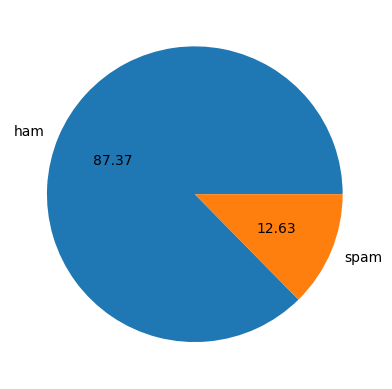

In [14]:
#plot the pie chart
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [15]:
# imbalance dataset

In [16]:
# step 2: Create new features (Characters, Words, Sentences)

In [17]:
import nltk

In [18]:
#num of character
df['text'].apply(len)
df['no_of_char'] = df['text'].apply(len)

In [19]:
#num of words
df['no_of_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [20]:
#num of sentences
df['no_of_sens'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [21]:
df.head()

,target,text,no_of_char,no_of_words,no_of_sens
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [22]:
# step3 : check numerical columns - Numerical Analysis
df[['no_of_char','no_of_words','no_of_sens']].describe()

,no_of_char,no_of_words,no_of_sens
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [23]:
#ham statistical summary
df[df['target']==0][['no_of_char','no_of_words','no_of_sens']].describe()

,no_of_char,no_of_words,no_of_sens
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [24]:
#spam statistical summary
df[df['target']==1][['no_of_char','no_of_words','no_of_sens']].describe()

,no_of_char,no_of_words,no_of_sens
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [25]:
import seaborn as sns

<Axes: xlabel='no_of_words', ylabel='Count'>

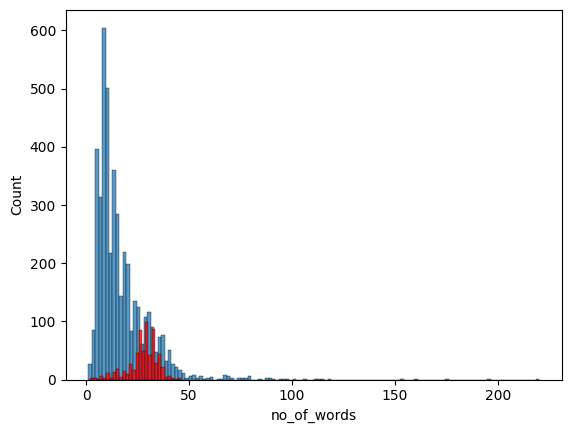

In [26]:
sns.histplot(df[df['target'] == 0]['no_of_words'])
sns.histplot(df[df['target'] == 1]['no_of_words'],color = 'red')

<Axes: >

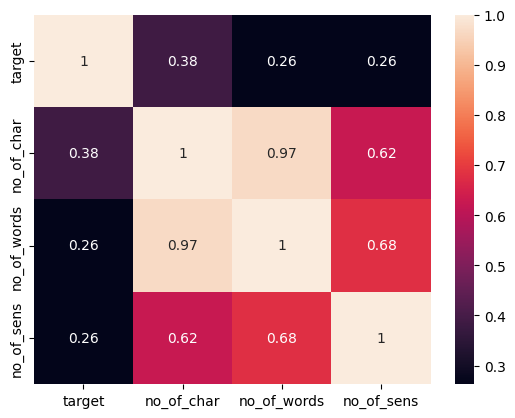

In [27]:
#Definition : A heatmap is a visual representation of correlation values using colors. Instead of numbers, it uses:
#Dark color → high correlation
#Light color → low correlation
#1.0 → strong relationship
#Close to 0 → weak relationship
#Diagonal values are always 1 (same variable)

#df.corr() only works on numerical data
sns.heatmap(df[['target','no_of_char','no_of_words','no_of_sens']].corr(), annot=True)

In [28]:
#since no_of_char with target is more co-related, so we will study that

## 3. Data Processing

In [29]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer 
ps = PorterStemmer()

In [30]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    l = []
    for ch in text:
        if ch.isalnum():
            l.append(ch)

    text = l[:]
    l.clear()
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            l.append(i)

    text = l[:]
    l.clear()
    for i in text:
        l.append(ps.stem(i))
    return " ".join(l)

In [31]:
transform_text('Hi ARE you 20% %$ of ef dancing')

'hi 20 ef danc'

In [32]:
#Now add a new column as transform_text

In [33]:
df['transform_text'] = df['text'].apply(transform_text)
df.head()

,target,text,no_of_char,no_of_words,no_of_sens,transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [34]:
# Word Cloud to show the import words in spam and ham text in bold and big way : there size depend on frequencies
!pip install wordcloud

In [35]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [36]:
#.str.cat(sep=" ")
#Combine all messages into one single string

# wc.generate(...)
# Create a word cloud from that combined text
# Counts word frequency
# Displays frequent words bigger

spam_wc = wc.generate(df[df['target']==1]['transform_text'].str.cat(sep=" "))

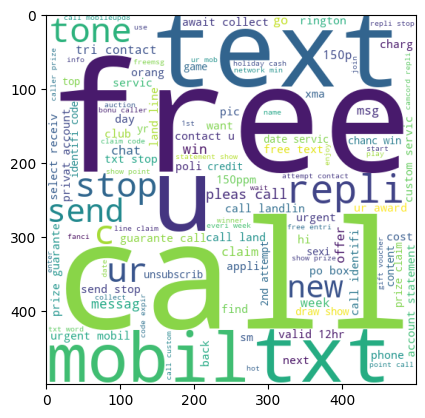

In [37]:
plt.imshow(spam_wc)

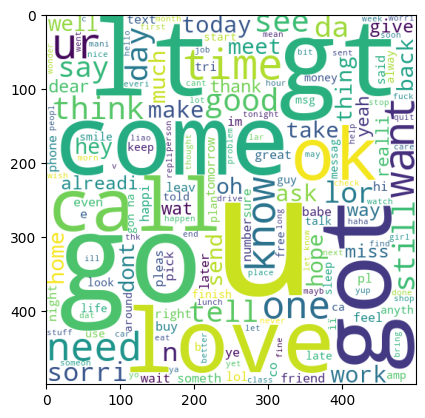

In [38]:
ham_wc = wc.generate(df[df['target']==0]['transform_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

In [39]:
# to get the top 30 words of spam and ham 

In [40]:
#Spam
spam_corpus=[]
for msg in df[df['target']==1]['transform_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)
        

In [41]:
len(spam_corpus)

9939

C:\Users\user\AppData\Local\Temp\ipykernel_4412\2061801669.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='word', y='count', data=df_top, palette='coolwarm')


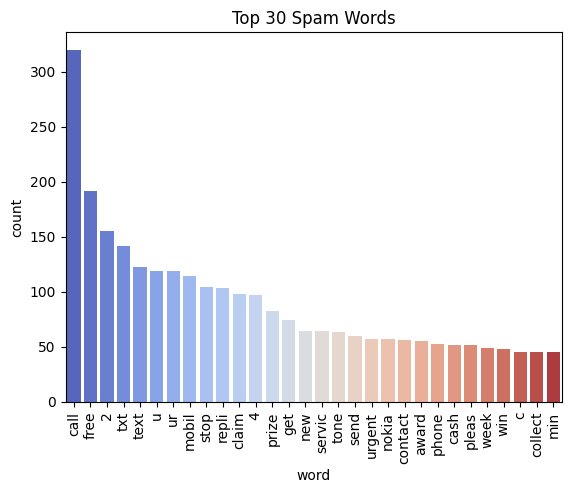

In [42]:
#count the frequencies and plot in bar
from collections import Counter

# Get top 30 words
top_words = Counter(spam_corpus).most_common(30)

# Convert to DataFrame
df_top = pd.DataFrame(top_words, columns=['word', 'count'])

# Plot
sns.barplot(x='word', y='count', data=df_top, palette='coolwarm')
plt.xticks(rotation='vertical')
plt.title("Top 30 Spam Words")
plt.show()

In [43]:
#ham
ham_corpus=[]
for msg in df[df['target']==0]['transform_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
        

C:\Users\user\AppData\Local\Temp\ipykernel_4412\2381789157.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='word', y='count', data=df_top, palette='coolwarm')


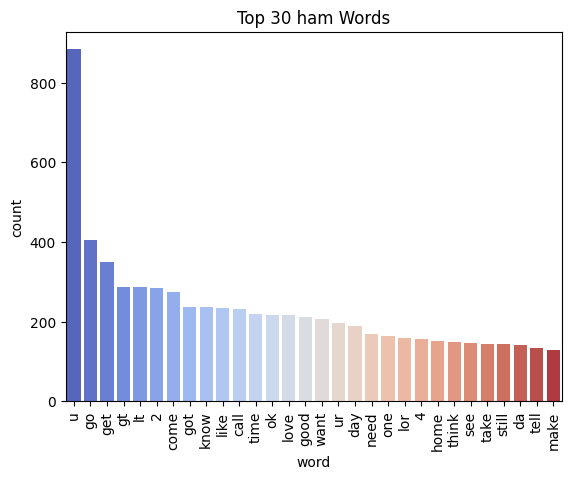

In [44]:
# Get top 30 words
top_words = Counter(ham_corpus).most_common(30)

# Convert to DataFrame
df_top = pd.DataFrame(top_words, columns=['word', 'count'])

# Plot
sns.barplot(x='word', y='count', data=df_top, palette='coolwarm')
plt.xticks(rotation='vertical')
plt.title("Top 30 ham Words")
plt.show()

## 4. Model building

In [45]:
# step1. import require libraries
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [46]:
# Step 2: Load the Dataset : already loaded & cleaned the data

In [73]:
# Step 3: Separate Independent and Dependent Features
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transform_text']).toarray()


In [74]:
y = df['target']

In [75]:
# Step 4: Split Data into Train and Test
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [76]:
# Create the Model Object
mnb = MultinomialNB()
gnb = GaussianNB()
bnb = BernoulliNB()

In [77]:
# Train the Model , Make Prediction Using Test Data & Compare different metrces of Prediction With Actual Output

In [78]:
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_pred1, y_test))
print(confusion_matrix(y_pred1, y_test))
print(precision_score(y_pred1, y_test))

0.874274661508704
[[790  24]
 [106 114]]
0.8260869565217391


In [79]:
bnb.fit(X_train,y_train)
y_pred1 = bnb.predict(X_test)
print(accuracy_score(y_pred1, y_test))
print(confusion_matrix(y_pred1, y_test))
print(precision_score(y_pred1, y_test))

0.9835589941972921
[[895  16]
 [  1 122]]
0.8840579710144928


In [80]:
mnb.fit(X_train,y_train)
y_pred1 = mnb.predict(X_test)
print(accuracy_score(y_pred1, y_test))
print(confusion_matrix(y_pred1, y_test))
print(precision_score(y_pred1, y_test))

0.9709864603481625
[[896  30]
 [  0 108]]
0.782608695652174


In [81]:
#Since precision score matter b/c data is imbalanced - so we go with tfidf  ---> mnb

## 5. Checking different activities for improving model performance

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [83]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [84]:
clfs = {
    'SVC' : svc,
    'KN' : knc, 
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
    'BgC': bc, 
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [85]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy,precision

In [86]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9747899159663865)

In [87]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9342359767891683
Precision -  0.85
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96


C:\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9487179487179487


In [88]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [89]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.968085,0.948718
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.934236,0.850000


In [90]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [91]:
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.970986
2,RF,Accuracy,0.973888
3,SVC,Accuracy,0.975822
4,ETC,Accuracy,0.974855
5,LR,Accuracy,0.955513
6,xgb,Accuracy,0.968085
7,GBDT,Accuracy,0.950677
8,BgC,Accuracy,0.958414
9,DT,Accuracy,0.934236


In [92]:
# model improve
# 1. Change the max_features parameter of TfIdf

In [93]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [94]:
#2. Use Scaling

In [95]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [96]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [97]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

## 6. Pickel the file to add in frontened

In [98]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))